# Bottom 3 Performing Sectors in the Stock Market

> This is a challenge proposed by Ricardo Sierra, a respected index fund manager and investor. Contrary to the usual approach of trying to identify the winners, the objective is to predict the three worst-performing sectors over the next six months from the 11 major U.S. stock market sectors. I highly recommend that you give it a try!

> This notebook presents a focused quantitative and fundamental analysis of the sectors with the greatest potential downside risk.

My forecast runs from **July 2026 to January 2027**.

---

## The challenge

I want to answer one question:

> Which three sectors are most likely to underperform the S&P 500?

I will compare:

- Price performance
- Valuations
- Momentum
- Economic sensitivity
- Interest rates
- Inflation
- Consumer strength
- Investor positioning
- Market Volatility

The S&P 500 ETF, `SPY`, will be my benchmark.

---

## The 11 sectors

The S&P 500 contains around 500 leading large U.S. companies.

Each company is placed into one of 11 GICS sectors. The sector ETFs track the S&P 500 companies belonging to their respective sector.

They do **not** track every U.S. company in that industry. Small and mid-sized companies outside the S&P 500 are excluded.

| Sector | ETF | What it tracks |
|---|---|---|
| Communication Services | `XLC` | All S&P 500 Communication Services companies |
| Consumer Discretionary | `XLY` | All S&P 500 Consumer Discretionary companies |
| Consumer Staples | `XLP` | All S&P 500 Consumer Staples companies |
| Energy | `XLE` | All S&P 500 Energy companies |
| Financials | `XLF` | All S&P 500 Financial companies |
| Health Care | `XLV` | All S&P 500 Health Care companies |
| Industrials | `XLI` | All S&P 500 Industrial companies |
| Information Technology | `XLK` | All S&P 500 Information Technology companies |
| Materials | `XLB` | All S&P 500 Materials companies |
| Real Estate | `XLRE` | All S&P 500 Real Estate companies |
| Utilities | `XLU` | All S&P 500 Utilities companies |

### How companies are weighted

The ETFs do not give every company the same weight.

Larger companies normally receive a greater weight based on their publicly available market value. Weight limits are applied to reduce excessive concentration in a single company.

The sector indices are rebalanced every quarter.

In simple terms:

> The S&P 500 represents the broader large-cap U.S. market, while each sector ETF represents one part of the S&P 500.

---

## Documents reviewed

| Source | Published by | Main purpose |
|---|---|---|
| World Economic Outlook | IMF | Growth, inflation and global risks |
| House View Q2 2026 | Aviva Investors | Energy shock and market outlook |
| 2026 Investment Outlook | J.P. Morgan | Economy, AI and sector themes |
| U.S. Sector Dashboard | S&P Dow Jones Indices | Returns, valuations and momentum |
| Sector Perspectives Q3 2026 | State Street | Outlook for all 11 sectors |
| Economic Projections | Federal Reserve | Growth, inflation and interest rates |

---

## Source dates

| Source | Date |
|---|---|
| J.P. Morgan Outlook | Late 2025 |
| Federal Reserve | March 18, 2026 |
| Aviva Investors | Q2 2026 |
| IMF Outlook | April 2026 |
| S&P Dashboard | June 30, 2026 |
| State Street | July 8, 2026 |

The most recent sources are **State Street** and the **S&P Dashboard**.

I will use them for current sector conditions.

The older reports will help explain how the economic outlook changed during 2026.

---

## Current macro regime

> Growth is still positive, but the economy is becoming more uneven.

### Growth

The U.S. economy is expected to grow by around **2.3% to 2.4%** in 2026.

Growth is supported by:

- AI investment
- Government spending
- Manufacturing
- Defence
- Higher-income consumers

### Inflation

Inflation is falling, but it remains above the Federal Reserve's 2% target.

The Federal Reserve expects **2.7% PCE inflation** in 2026.

### Interest rates

Interest rates remain relatively high.

The Federal Reserve expects a year-end policy rate of around **3.4%**.

This makes borrowing more expensive for consumers and companies.

### Consumers

The economy is increasingly divided.

Higher-income consumers remain strong.

Lower- and middle-income consumers face:

- Higher prices
- Expensive credit
- Lower savings
- Weak real-income growth
- Rising delinquencies

This is especially important for Consumer Discretionary and Consumer Staples.

### AI investment

AI remains one of the strongest parts of the economy.

It supports:

- Technology
- Industrials
- Utilities
- Materials
- Data centres

The main risk is that companies spend too much before producing enough revenue.

### Manufacturing

Manufacturing is improving.

New orders, capital spending, defence investment and inventory rebuilding support Industrials and Materials.

### Energy

Energy is the most uncertain part of the outlook.

My base case assumes:

- Oil supply normalises
- Geopolitical risk falls
- Oil prices lose some support
- Energy underperforms

If the Middle East conflict escalates again, this view could be wrong.

---

## Macro summary

| Factor | Current view |
|---|---|
| Growth | Positive but uneven |
| Inflation | Above target |
| Interest rates | Still restrictive |
| Consumers | Increasingly fragile |
| AI investment | Strong |
| Manufacturing | Improving |
| Oil | Normalising, but uncertain |
| Recession risk | Elevated, but not the base case |

In simple terms:

> The economy is still growing, but inflation, high rates and consumer weakness are creating clear sector-level risks.

---

## Initial candidates

Based on the research, my first candidates are:

1. **Consumer Discretionary**
2. **Consumer Staples**
3. **Energy**

Energy is the least certain choice.

If oil prices rise again, I may replace Energy with **Communication Services**.

---

## Reading order

1. **State Street, pages 1–3**  
   Sector overview.

2. **S&P Dashboard, pages 1 and 7**  
   Performance and valuations.

3. **J.P. Morgan, pages 1–4 and 7**  
   Consumers, AI and sectors.

4. **Aviva, pages 5–7, 16–18 and 34**  
   Energy and consumer risks.

5. **IMF, pages 6–10 and 25–26**  
   Economic scenarios.

6. **Federal Reserve, pages 2, 4, 10 and 12**  
   Growth, inflation and rates.

7. **State Street, pages 9–15**  
   Final review of the main candidates.

---

## Sector Returns, Valuation and Momentum Dashboard

This section compares the historical returns, relative momentum and valuation of the 11 sector ETFs.

Returns and momentum are calculated from the ETF daily-return data through July 8, 2026. Valuation data come from the S&P U.S. Sector Dashboard and are dated June 30, 2026.

Momentum is kept deliberately simple. It is measured as each sector's six-month return minus the six-month return of SPY.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


DATA_FILE = Path("../data/sectors/daily_returns.csv")
INFORMATION_CUTOFF = pd.Timestamp("2026-07-08")

daily_returns = pd.read_csv(
    DATA_FILE,
    index_col="Date",
    parse_dates=True,
)

daily_returns = daily_returns.sort_index()

# Prevent the notebook from using information after the forecast cutoff.
daily_returns = daily_returns.loc[
    daily_returns.index <= INFORMATION_CUTOFF
].copy()

SECTOR_NAMES = {
    "XLC": "Communication Services",
    "XLY": "Consumer Discretionary",
    "XLP": "Consumer Staples",
    "XLE": "Energy",
    "XLF": "Financials",
    "XLV": "Health Care",
    "XLI": "Industrials",
    "XLK": "Technology",
    "XLB": "Materials",
    "XLRE": "Real Estate",
    "XLU": "Utilities",
}

SECTOR_TICKERS = list(SECTOR_NAMES)

analysis_date = daily_returns.index.max()

print(f"Latest return data used: {analysis_date.date()}")

Latest return data used: 2026-07-08


In [7]:
RETURN_WINDOWS = {
    "Return_1M": 21,
    "Return_3M": 63,
    "Return_6M": 126,
    "Return_12M": 252,
}


def compounded_return(return_series, trading_days):
    selected_returns = return_series.dropna().tail(trading_days)

    if len(selected_returns) < trading_days:
        return np.nan

    return (1 + selected_returns).prod() - 1


sector_returns = pd.DataFrame(
    {
        period: daily_returns[SECTOR_TICKERS].apply(
            compounded_return,
            trading_days=trading_days,
        )
        for period, trading_days in RETURN_WINDOWS.items()
    }
)

spy_return_6m = compounded_return(
    daily_returns["SPY"],
    trading_days=126,
)

sector_returns["Momentum_6M_vs_SPY"] = (
    sector_returns["Return_6M"]
    - spy_return_6m
)

sector_returns["Momentum_Rank"] = (
    sector_returns["Momentum_6M_vs_SPY"]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

sector_returns.index.name = "Ticker"

print(f"SPY six-month return: {spy_return_6m:.2%}")

SPY six-month return: 8.96%


In [8]:
# --------------------------------------------------
# Important note about valuation
# --------------------------------------------------
#
# Valuation cannot be calculated from ETF prices or returns alone.
# The P/E and Value Score figures below come from the S&P U.S.
# Sector Dashboard and are dated June 30, 2026.
#
# The S&P Dashboard defines P/E using trailing reported earnings.
# Therefore, these are trailing P/E ratios, not forward estimates.
#
# Raw P/E ratios should not be treated as directly comparable across
# sectors. Different sectors naturally operate with different margins,
# growth rates, capital requirements and accounting structures.
#
# For example, Technology normally trades at a higher P/E than Energy
# or Financials. A higher P/E does not automatically mean that a sector
# is a better candidate for underperformance.
#
# The P/E figures are included as descriptive context. The S&P Value
# Score is more appropriate for cross-sector comparison because it
# combines normalized earnings-to-price, book-to-price and
# sales-to-price information.
#
# These valuation observations will not be included in the initial
# predictive model. Doing so properly would require a historical
# point-in-time valuation series for every prediction date.


valuation_data = pd.DataFrame(
    {
        "PE": {
            "XLC": 23.3,
            "XLY": 34.7,
            "XLP": 28.7,
            "XLE": 20.2,
            "XLF": 17.2,
            "XLV": 31.3,
            "XLI": 32.2,
            "XLB": 39.0,
            "XLRE": 35.4,
            "XLK": 42.0,
            "XLU": 20.4,
        },
        "Value_Score": {
            "XLC": -0.01,
            "XLY": -0.16,
            "XLP": 0.04,
            "XLE": 0.28,
            "XLF": 0.19,
            "XLV": -0.06,
            "XLI": -0.12,
            "XLB": 0.05,
            "XLRE": -0.08,
            "XLK": -0.21,
            "XLU": 0.08,
        },
    }
)

valuation_data.index.name = "Ticker"

valuation_data

,PE,Value_Score
Ticker,,
XLC,23.3,-0.01
XLY,34.7,-0.16
XLP,28.7,0.04
XLE,20.2,0.28
XLF,17.2,0.19
XLV,31.3,-0.06
XLI,32.2,-0.12
XLB,39.0,0.05
XLRE,35.4,-0.08


In [9]:
sector_dashboard = sector_returns.join(
    valuation_data,
    how="left",
)

sector_dashboard.insert(
    0,
    "Sector",
    pd.Series(SECTOR_NAMES),
)

sector_dashboard = sector_dashboard.sort_values(
    "Momentum_Rank"
)

sector_dashboard

,Sector,Return_1M,Return_3M,Return_6M,Return_12M,Momentum_6M_vs_SPY,Momentum_Rank,PE,Value_Score
Ticker,,,,,,,,,
XLK,Technology,0.007301,0.321519,0.257379,0.430660,0.167747,1,42.0,-0.21
XLE,Energy,-0.028941,-0.069133,0.202108,0.330374,0.112477,2,20.2,0.28
XLI,Industrials,0.038374,0.100949,0.134639,0.227302,0.045008,3,32.2,-0.12
XLRE,Real Estate,-0.003649,0.067519,0.108984,0.101066,0.019353,4,35.4,-0.08
XLP,Consumer Staples,0.018403,0.045724,0.104769,0.056272,0.015137,5,28.7,0.04
XLB,Materials,-0.005579,0.005343,0.085690,0.128826,-0.003941,6,39.0,0.05
XLU,Utilities,0.029304,-0.013407,0.076553,0.137055,-0.013079,7,20.4,0.08
XLV,Health Care,0.065393,0.112204,0.055766,0.229047,-0.033865,8,31.3,-0.06
XLF,Financials,0.054734,0.105905,-0.012184,0.059663,-0.101815,9,17.2,0.19


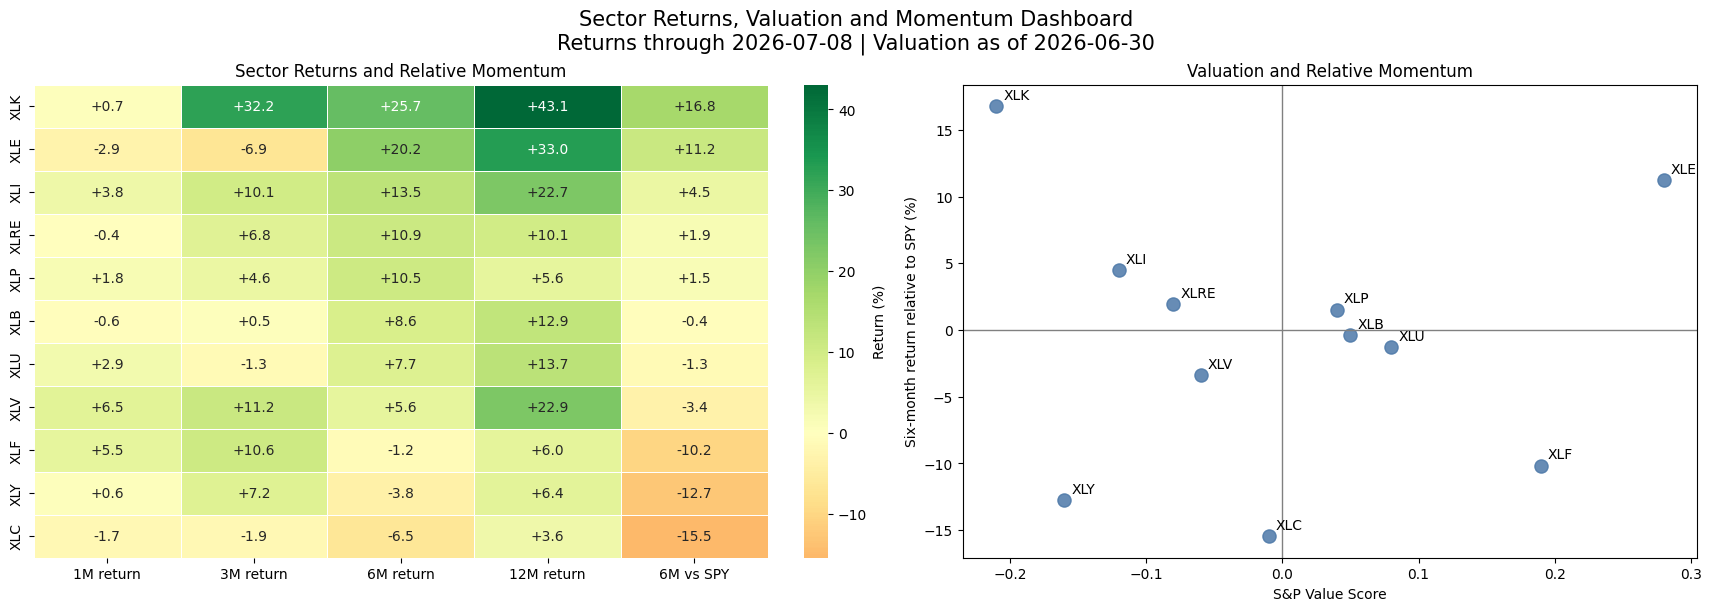

In [10]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 6),
    constrained_layout=True,
)


# --------------------------------------------------
# Returns and momentum heatmap
# --------------------------------------------------

heatmap_columns = [
    "Return_1M",
    "Return_3M",
    "Return_6M",
    "Return_12M",
    "Momentum_6M_vs_SPY",
]

heatmap_data = (
    sector_dashboard[heatmap_columns] * 100
)

heatmap_data.columns = [
    "1M return",
    "3M return",
    "6M return",
    "12M return",
    "6M vs SPY",
]

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="+.1f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Return (%)"},
    ax=axes[0],
)

axes[0].set_title("Sector Returns and Relative Momentum")
axes[0].set_xlabel("")
axes[0].set_ylabel("")


# --------------------------------------------------
# Value score versus relative momentum
# --------------------------------------------------

x_values = sector_dashboard["Value_Score"]
y_values = sector_dashboard["Momentum_6M_vs_SPY"] * 100

axes[1].scatter(
    x_values,
    y_values,
    s=90,
    color="#4C78A8",
    alpha=0.85,
)

for ticker in sector_dashboard.index:
    axes[1].annotate(
        ticker,
        (
            x_values.loc[ticker],
            y_values.loc[ticker],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )

axes[1].axvline(
    0,
    color="grey",
    linewidth=1,
)

axes[1].axhline(
    0,
    color="grey",
    linewidth=1,
)

axes[1].set_title("Valuation and Relative Momentum")
axes[1].set_xlabel("S&P Value Score")
axes[1].set_ylabel("Six-month return relative to SPY (%)")

fig.suptitle(
    "Sector Returns, Valuation and Momentum Dashboard\n"
    f"Returns through {analysis_date.date()} | "
    "Valuation as of 2026-06-30",
    fontsize=15,
)

plt.show()

Steps:
- ☐ Sector returns, valuation and momentum dashboard
- ☐ Feature engineering
- ☑ S&P 500 volatility quant model
- ☑ Sector volatility quant model
- ☐ Predictive methodology and walk-forward validation
- ☐ Probability of underperformance for all 11 sectors
- ☐ Base-case ranking
- ☐ Oil-shock sensitivity analysis
- ☐ Final three sectors and investment rationale
- ☐ Limitations and references



`Script:` We have looked at other's fundamental conclusions and calculations and discussed their ideas, now its time to come up with our own. Lets start by looking at each sectors volatility and compare it to our benchmark.
  

## Simple Historical Volatility Model
Here we model volatility by calculating a three month rolling standard deviation. 

In [ ]:
# Change this path only if the notebook is in a different folder
DATA_FILE = Path("../data/sectors/daily_returns.csv")

daily_returns = pd.read_csv(
    DATA_FILE,
    index_col="Date",
    parse_dates=True,
)

daily_returns = daily_returns.sort_index()

In [12]:
TRADING_DAYS_IN_WINDOW = 63
TRADING_DAYS_PER_YEAR = 252

volatility_3m = daily_returns.rolling(
    window=TRADING_DAYS_IN_WINDOW,
    min_periods=TRADING_DAYS_IN_WINDOW,
).std(ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR)

In [13]:
# Turn it into percentage
volatility_3m_percent = volatility_3m * 100

In [14]:
from IPython.display import display, HTML
import pandas as pd

latest_volatility = (
    volatility_3m_percent.iloc[-1]
    .sort_values(ascending=False)
    .rename("Annualized_Volatility_3M_Percent")
    .to_frame()
)

volatility_guide = pd.DataFrame({
    "Annualized Std Dev": ["< 10%", "10%–20%", "20%–30%", "> 30%"],
    "Volatility Level": ["Low", "Moderate", "High", "Very High"],
    "Typical Examples": [
        "Treasury bonds, utilities, money-market funds",
        "S&P 500, diversified large-cap stocks",
        "Growth stocks, small caps, emerging markets",
        "Biotech, IPOs, meme stocks, cryptocurrencies",
    ],
})

display(HTML(f"""
<div style="display: flex; gap: 40px; align-items: flex-start;">

  <div>
    <h3>Latest 3-Month Volatility</h3>
    {latest_volatility.round(2).to_html()}
  </div>

  <div>
    <h3>Interpretation Guide</h3>
    {volatility_guide.to_html(index=False)}
  </div>

</div>
"""))

,Annualized_Volatility_3M_Percent
XLK,32.54
XLE,25.28
XLI,21.13
XLY,20.24
XLB,20.17
XLV,18.05
XLU,17.85
XLRE,16.58
XLP,15.68
XLC,15.42
